## Welcome to The Disco Biscuits Analysis Project

The Disco Biscuits are a "trance-fusion" Jam Band that was formed in 1995, heralding from Philladelphia Pennsylvania in the United States.  Their unique sound and catalog has evolved over the nearly 30 years of their history, but one constant throughout this period is that they continue to push the envelope of improvisational music.  One of the key elements that sets the Disco Biscuits apart is ther experimentation with their song catalog and finding new ways to keep their fans on their toes.  The band effortlessly blends one song into another, creating what are known as "segues" (typically denoted with a ">" in the track listing of a show) where the band improvises or "jams" between songs, creating a completely new sound on the fly, which may never be heard again after that show.  Songs are often rearranged into unique renditions, such as "inverted" songs (where a song is broken up and the "ending" section is played first, then the band jams into the "beginning" section of the song), or "dyslexic" versions (where the song is again broken up, but entirely different songs are inserted into the middle, and the band eventually returns to finish the song that was started earlier).  "Palindrome" sets are created when the band plays a series of songs that are split up and revisited in order to have the setlist read the same forwards and backwards (e.g. Overture > Basis for a Day > Vassillios > Basis for a Day > Overture).

The dataset in this project comes from a fan-created website, [www.discobiscuits.net](www.discobiscuits.net), (which I have contributed to over the years) that catalogs the entire history of the band, including all setlists, venues, and key info and annotations about different renditions and versions of the songs.  The rich historical information available on this site, along with the constant evolution of the band and its catalog, lends itself perfectly to an investigative project that allows us to explore the music of this band over the decades, which continues to draw fans to live shows that are always unique and mind-blowing.

I reached out to the discobiscuits.net site maintainers and requested a CSV export of some of the key tables that makes up the Postgresql database backing the site.  These tables inclued the song catalog (songa.csv), information about the venues they have played (venues.csv), the show listing (shows.csv), the order of songs within particular shows (tracks.csv), and notes about the composition and unique attributes of individual versions of a song (annotation.csv).  As this data comes from a relational database, there are foreign keys linking records from one table to records on another (e.g. the tracks table has a foreign key to the songs and shows tables, which in turn has a foreign key to the venues table).

In [17]:
# we will use pandas to load the CSV files and preview the dataframes
import pandas as pd

# Load the CSV files
venues_df = pd.read_csv('data/venues.csv')
bands_df = pd.read_csv('data/bands.csv')
authors_df = pd.read_csv('data/authors.csv')
songs_df = pd.read_csv('data/songs.csv')
shows_df = pd.read_csv('data/shows.csv')
tracks_df = pd.read_csv('data/tracks.csv')
annotations_df = pd.read_csv('data/annotations.csv')

The venues data contains information about each venue the band has played, including its name and city/state.

Let's drop some unimportant columns from this dataset which are not relevant to our project, and preview this table's data.

In [18]:
venues_df.drop(columns=['slug', 'street', 'latitude', 'longitude', 'phone', 'website', 'created_at', 'updated_at'], axis=1, inplace=True)
venues_df_preview = venues_df.head()
venues_df_preview

,id,name,city,state,country,postal_code,legacy_id,times_played
0,49ce1870-7f87-4977-9f69-f844d964e135,Monopole,Plattsburgh,NY,NaN,NaN,NaN,0
1,1c9aeebd-707c-4d30-9b00-83fef9c841eb,"Campus Pub, SUNY Binghamton",Binghamton,NY,NaN,NaN,58.0,1
2,f479d7ba-e37a-4dfa-880a-7cdf38278f13,"College Green, Brown University",Providence,RI,NaN,NaN,77.0,1
3,2c52099e-f5a0-44fc-8c5b-d87734942e73,3:19 Club,Chico,CA,NaN,NaN,3.0,1
4,8c3e9a81-d10e-46de-835a-67050a55bf40,Cabaloosa,New Paltz,NY,NaN,NaN,49.0,4


The Songs dataset contains information about each song, including its title, number of times played, when it was last played, and how many times per year it was played.

We can get rid of some unimportant columns that are not relevant to this project.

In [3]:
songs_df.drop(columns=['lyrics', 'tabs', 'slug', 'legacy_id', 'legacy_author', 'notes', 'legacy_abbr', 'history', 'featured_lyric', 'guitar_tabs_url', 'created_at', 'updated_at'], axis=1, inplace=True)
songs_df_preview = songs_df.head()
songs_df_preview

,id,title,cover,author_id,times_played,date_last_played,yearly_play_data,longest_gaps_data,most_common_year,least_common_year
0,d9fe0cfe-dd11-4d8a-983f-a3c4e27bf01a,Take a Bow,True,0741948c-afa5-4f19-bb97-126844a6fa0a,2,2007-08-30,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""0"": {""date"": ""2007-08-18"", ""previous"": null,...",2007,2007.0
1,26e4e607-5b8c-4f01-914a-59c5f2e0fda1,She's A Bad Mama Jama,True,198854b8-6151-4ac8-8a2d-0ebc633d59ff,1,2016-03-25,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""0"": {""date"": ""2016-03-25"", ""previous"": null,...",2016,2016.0
2,a2271b6e-292b-43a4-a16f-6c880c77ad09,Her Majesty,True,4c05e770-de89-4034-970d-7841d064b9e6,2,1995-12-02,"{""1995"": 2, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""0"": {""date"": ""1995-11-09"", ""previous"": null,...",1995,1995.0
3,00599772-dc5b-4e4a-85ae-f3ad79ed0896,Bad Love,True,9086752c-7d9a-4805-8a0a-9084c69282c5,1,1999-03-06,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""0"": {""date"": ""1999-03-06"", ""previous"": null,...",1999,1999.0
4,fecddfb7-8f2a-4129-b6b2-0dfdfd884113,I Wanna Be Sedated,True,67da6e12-008c-476e-bfc2-77da47eeee1a,4,2007-10-24,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""0"": {""date"": ""2007-08-15"", ""previous"": null,...",2007,2007.0


If we are specifically interested in songs that are NOT covers of songs written by other bands, we can create a filtered dataframe containing only original songs:

In [4]:
original_songs_df = songs_df[songs_df['cover'] == False]
original_songs_df_preview = original_songs_df.head()
original_songs_df_preview

,id,title,cover,author_id,times_played,date_last_played,yearly_play_data,longest_gaps_data,most_common_year,least_common_year
7,d90fb6b4-270f-4307-9cd8-c21fa23b2c18,Humuhumunukunukuapua'a,False,2c0efbda-2ac6-4789-95a4-de69013a617b,91,2024-04-05,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""35"": {""date"": ""2009-10-10"", ""previous"": ""200...",2002,2005.0
8,9175f0b7-7768-4a78-9eb8-c3d1ce51bb09,Camera B,False,4338604b-38e0-432c-855b-bcd9091d4409,17,2006-11-14,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""8"": {""date"": ""2006-11-08"", ""previous"": ""2006...",2006,2005.0
13,7e7124e2-22bf-4424-9c14-08cd200822b4,Stars in the Sky,False,e29db38d-5b63-4e2c-b5bc-8f4ed3fe1c64,8,2024-11-13,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""10"": {""date"": ""2024-07-13"", ""previous"": ""202...",2024,2019.0
18,c6c86090-0e1d-4e07-815a-3f6f9f0fa26e,The Devil's Waltz,False,7a01161d-ab82-40e5-99a1-49945cf0be96,133,2021-06-26,"{""1995"": 0, ""1996"": 5, ""1997"": 39, ""1998"": 38,...","{""62"": {""date"": ""2016-06-02"", ""previous"": ""201...",1997,2012.0
19,259c5665-c6b3-4582-823e-4c3e735c031c,Salute To Sammy,False,e29db38d-5b63-4e2c-b5bc-8f4ed3fe1c64,1,2005-08-27,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""0"": {""date"": ""2005-08-27"", ""previous"": null,...",2005,2005.0


In [5]:
shows_df.drop(columns=['slug', 'notes', 'legacy_id', 'created_at', 'updated_at', 'relisten_url', 'show_photos_count', 'show_youtubes_count', 'reviews_count'], axis=1, inplace=True)
shows_df_preview = shows_df.head()
shows_df_preview

,id,date,venue_id,band_id,likes_count,average_rating
0,73e7ad08-2e2c-4a83-a768-aaba6e004716,1998-05-23,54becbfa-b56c-452d-803e-0201fb375d2e,db7f2c5d-2727-41fd-bd6f-e91c74164f09,0,0.000000
1,25bcc399-ce8f-4683-a2a6-5486eeba347d,2021-07-09,2b839f0d-5ce0-402a-a7ae-aee8968dc3e9,db7f2c5d-2727-41fd-bd6f-e91c74164f09,0,4.419355
2,77a948be-4d60-4bc4-8ddc-688e367039b1,1999-02-05,023caca8-36d3-42ef-adbe-dc5471812061,db7f2c5d-2727-41fd-bd6f-e91c74164f09,0,3.500000
3,c583ecd1-8fb4-4c65-9558-51f3f7a8558a,2021-05-18,772346af-6a44-47b2-980d-aba4db9f114f,db7f2c5d-2727-41fd-bd6f-e91c74164f09,0,3.913043
4,99ed5f5e-e062-4fe3-a4e1-521d11a8124c,2021-11-27,8dfeef2a-b9f9-4b71-8346-ebbd242f31af,db7f2c5d-2727-41fd-bd6f-e91c74164f09,0,4.320000


The tracks table provides data about each time a song was played, along with its position in the set, and what track came before/after this track.

In [6]:
tracks_df.drop(columns=['slug', 'created_at', 'updated_at', ], axis=1, inplace=True)
tracks_df_preview = tracks_df.head()
tracks_df_preview

,id,show_id,song_id,set,position,segue,likes_count,note,all_timer,previous_track_id,next_track_id,average_rating
0,70848664-b33f-46cc-a7b3-f3b5688ee3f3,5f40bdf9-32ec-4061-9b29-b5341e32eefe,e5a0b3a1-5e2b-409c-9b5c-0beafff15c62,S1,2,NaN,0,NaN,False,a1528807-d341-4cad-af3d-e9385fab7f5b,6915b2c5-9ff5-4b5d-b731-32aeee1f4fe5,0.0
1,f755b828-f90e-4737-838b-56f32f4d5776,5f40bdf9-32ec-4061-9b29-b5341e32eefe,f98418ae-748e-4459-8a5c-2b5fefa4c81d,S1,4,NaN,0,NaN,False,6915b2c5-9ff5-4b5d-b731-32aeee1f4fe5,9875a257-ba2b-4f98-88bf-7696d6b7bee9,0.0
2,9875a257-ba2b-4f98-88bf-7696d6b7bee9,5f40bdf9-32ec-4061-9b29-b5341e32eefe,2d5b75b8-339a-4af1-b136-dc6857d0bc54,S1,5,NaN,0,NaN,False,f755b828-f90e-4737-838b-56f32f4d5776,f43b0ffa-22f1-4413-89ed-f3b07868b3e0,0.0
3,f43b0ffa-22f1-4413-89ed-f3b07868b3e0,5f40bdf9-32ec-4061-9b29-b5341e32eefe,5147e937-0370-4802-a690-2a54e3a1d77e,S1,6,NaN,0,NaN,False,9875a257-ba2b-4f98-88bf-7696d6b7bee9,a96b2e47-b6e1-4f61-b069-2328ecfef3b5,0.0
4,278fbf8d-af97-43df-916a-4e259e2774b8,5f40bdf9-32ec-4061-9b29-b5341e32eefe,31d0c9ec-224a-426d-92af-daf8fe81e88f,S1,8,NaN,0,NaN,False,a96b2e47-b6e1-4f61-b069-2328ecfef3b5,d54a92c0-7120-4025-9a29-b10531abc7dc,0.0


The annotations table contains information about individual tracks, with notes about how the song was played in that particular instance.  This gives us details about whether it was inverted, dyslexic, as well as other arbitrary facts such as "first time played" or indicating a guest performer, etc.

In [7]:
annotations_df.drop(columns=['created_at', 'updated_at', ], axis=1, inplace=True)
annotations_df_preview = annotations_df.head()
annotations_df_preview

,id,track_id,desc
0,01476ed6-bd97-4c13-8698-4a75d90007b3,47377c59-2bce-4558-a0d4-906777a95470,With 'Slipknot!' and 'Disco Bisquick' teases.
1,8c4d8cb5-19cf-4fc0-bebc-d450bd819529,104b4572-a59c-49d1-afba-e99343513f36,No lyrics but there's some distinct Barfly jam...
2,15b17451-5b61-4720-b8ec-46822583a374,85b15ff6-591a-4404-989b-20338151ffcd,With Elliot Levin on saxophone.
3,ba52d549-0d20-415e-b2ce-9c738c969e6d,c6b0ebdd-9a12-464a-a7dc-5b40502c3397,With Elliot Levin on saxophone.
4,63eaf8bc-9a91-4516-b4be-2ab824d91b68,f7330756-4cfa-4b8d-930b-5f45c627f9ab,With Elliot Levin on saxophone.


## Analysis

Now we will begin to investigate the datasets to glean interesting information from them.

### Most commonly played songs
First, let's begin by taking a look at the top 20 most commonly played songs of all time.

In [19]:
most_played_songs = songs_df[['title', 'times_played']].sort_values(by='times_played', ascending=False).head(20)

most_played_songs

,title,times_played
219,I-Man,367
427,Morph Dusseldorf,359
211,Helicopters,335
207,Basis For A Day,328
467,M.E.M.P.H.I.S.,310
382,Shem-Rah Boo,308
394,Mindless Dribble,291
100,Aceetobee,288
487,Above The Waves,282
480,Little Shimmy In A Conga Line,280


### Common set openers
Now let's look at what songs were most commonly used to open a particular set.  The tracks table data indicates the set number (e.g. S1, S2, S3, or E1 to indicate the Encore), as well as the track's position in the set.

In [9]:
# join the tracks and songs dataframes on the song_id column to get the song title for each track
tracks_songs_merged = tracks_df.merge(songs_df, left_on='song_id', right_on='id', how='inner')

# we are interested in all the tracks where the position is 1, which means they are the opening songs
opening_songs = tracks_songs_merged[tracks_songs_merged['position'] == 1]

# Find the most frequent song opening each set (S1, S2, S3, etc.)
most_frequent_openers = (
    opening_songs.groupby('set', as_index=False)['title']
    # We specify the aggregation function to apply the lambda function to the grouped
    # data to find the mode (most frequently occurring value) and number of times it occurred.
    # In case there is a tie, we break it by selecting the first value (.iloc[0])
    .agg([
        ('most_frequent_opener', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        # open_count is the number of times the most frequent opener was played
        ('open_count', lambda x: x.value_counts().iloc[0] if not x.mode().empty else 0)
    ])
)

# re-order the output to match the desired order (sets first, then encores)
desired_order = ['S1', 'S2', 'S3', 'S4', 'E1', 'E2']
most_frequent_openers_reordered = most_frequent_openers.set_index('set').loc[desired_order].reset_index()

most_frequent_openers_reordered

,set,most_frequent_opener,open_count
0,S1,Jam,66
1,S2,Jam,47
2,S3,Mindless Dribble,5
3,S4,Magellan,1
4,E1,Home Again,46
5,E2,Above The Waves,1


As seen in the output above, the most common set 1 and set 2 opener is listed as "Jam", however this is not an actual song.  This means the band started the set by improvising together for a while, before eventually transitioning into the first song.  Let's exclude these from the output to get more meaningful data about which song actually came first in the set.

In [10]:
# Exclude the "Jam" track from the data
filtered_opening_songs = opening_songs[opening_songs['title'] != 'Jam']

# Find the most frequent song opening each set again.
most_frequent_openers_filtered = (
    filtered_opening_songs.groupby('set', as_index=False)['title']
    # We specify the aggregation function to apply the lambda function to the grouped
    # data to find the mode (most frequently occurring value) and number of times it occurred.
    # In case there is a tie, we break it by selecting the first value (.iloc[0])
    .agg([
        ('most_frequent_opener', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        # open_count is the number of times the most frequent opener was played
        ('open_count', lambda x: x.value_counts().iloc[0] if not x.mode().empty else 0)
    ])
)

# re-order the output to match the desired order (sets first, then encores)
desired_order = ['S1', 'S2', 'S3', 'S4', 'E1', 'E2']
most_frequent_openers_reordered = most_frequent_openers_filtered.set_index('set').loc[desired_order].reset_index()

most_frequent_openers_reordered

,set,most_frequent_opener,open_count
0,S1,M.E.M.P.H.I.S.,55
1,S2,Mindless Dribble,38
2,S3,Mindless Dribble,5
3,S4,Magellan,1
4,E1,Home Again,46
5,E2,Above The Waves,1


### Common song pairings
Now, let's discover which songs are often paired together, that is, those which frequently follow one another in the set list.

In [12]:
# Merge the tracks data with the songs data to include song titles for clarity
tracks_with_titles_df = tracks_df.merge(songs_df[['id', 'title']], left_on='song_id', right_on='id', suffixes=('', '_song'))

# Create a dataset to capture transitions (song title pairs and segue information)
transitions_df = tracks_with_titles_df[['title', 'next_track_id', 'segue']].merge(
    tracks_with_titles_df[['id', 'title']], left_on='next_track_id', right_on='id', suffixes=('_current', '_next')
)

# Calculate frequency of each transition
transitions_df = transitions_df[['title_current', 'title_next', 'segue']].value_counts().reset_index()
transitions_df.columns = ['Song_Current', 'Song_Next', 'Segue', 'Frequency']

# Sort transitions by frequency for the most common pairs
most_common_transitions = transitions_df.sort_values(by='Frequency', ascending=False)

most_common_transitions


,Song_Current,Song_Next,Segue,Frequency
0,Stone,The Devil's Waltz,>,117
1,Shem-Rah Boo,Down To The Bottom,>,35
2,The Very Moon,Voices Insane,>,18
3,Highwire,I Remember When,>,18
4,Mindless Dribble,Helicopters,>,15
...,...,...,...,...
6015,42,Floodlights,>,1
6016,42,Gamma Goblins,>,1
6017,42,Hot Air Balloon,>,1
6018,42,Humuhumunukunukuapua'a,>,1


### New song introductions by year
Next, we'd like to explore the rate at which the band has produced new songs.  Because the songs dataset does not contain a column indicating when the song was first played, we must instead gather this information by joining the songs and tracks data, along with the show data.

In [13]:
# Ensure the 'date' column in shows_df is a datetime type
shows_df['date'] = pd.to_datetime(shows_df['date'], errors='coerce')

# Extract the year from the show date
shows_df['year'] = shows_df['date'].dt.year

# Merge tracks with shows to get the date and year of each track's performance
tracks_shows_merged = tracks_df.merge(shows_df, left_on='show_id', right_on='id', how='inner')

# Merge the resulting DataFrame with songs to get the song titles and IDs
complete_data = tracks_shows_merged.merge(songs_df, left_on='song_id', right_on='id', how='inner')

# Find the first year each song was played by grouping by song and finding the earliest year
songs_first_played_year = (
    complete_data.groupby('song_id', as_index=False)
    .agg({'year': 'min'})
    .rename(columns={'year': 'first_played_year'})
)

songs_first_played_counts = (
    songs_first_played_year.groupby('first_played_year', as_index=False)
    .size()
    .rename(columns={'first_played_year': 'year', 'size': 'number_of_songs'})
    .sort_values(by='year')
)

songs_first_played_counts

,year,number_of_songs
0,1995,54
1,1996,21
2,1997,20
3,1998,31
4,1999,19
5,2000,31
6,2001,27
7,2002,18
8,2003,35
9,2004,5


We can use the matplotlib library to create a line graph of the data for each year to visually show the rate of new song introduction

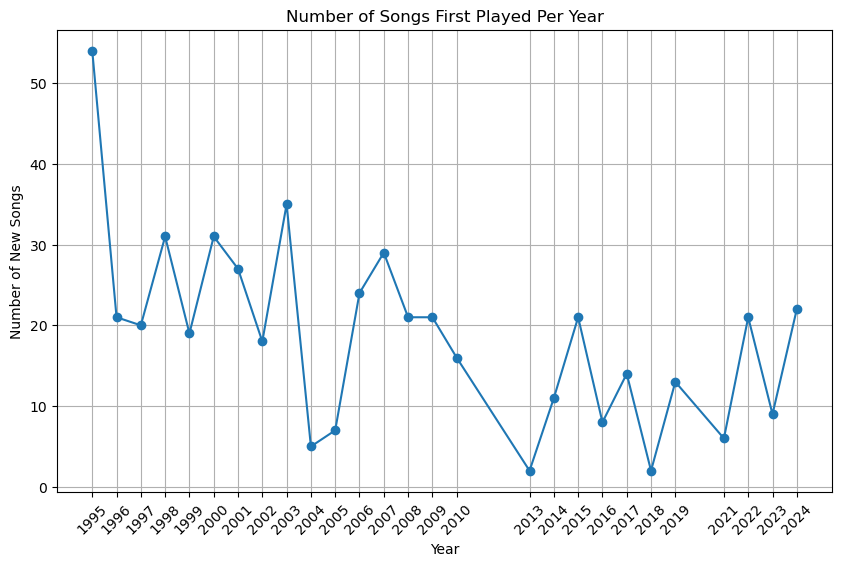

In [235]:
# import the matplotlib library to create the line graph
import matplotlib.pyplot as plot

# Create a line graph for the number of songs first played each year
plot.figure(figsize=(10, 6))
plot.plot(songs_first_played_counts['year'], songs_first_played_counts['number_of_songs'], marker='o', linestyle='-')
plot.title('Number of Songs First Played Per Year')
plot.xlabel('Year')
plot.ylabel('Number of New Songs')
plot.xticks(ticks=songs_first_played_counts['year'], labels=songs_first_played_counts['year'], rotation=45)  # Set all years as labels
plot.grid(True)
plot.show()

The data above shows us the frequency of new songs being introduced, and revels some interesting information.  There is a notable gap between 2010 and 2013, where the band was going through a period of upheaval and internal discord.  Tensions were high between band members, and the guitarist, Jon "Barber" Gutwillig, suffered a broken wrist in 2010 after punching a paper towel dispenser in frustration after a particularly unsatisfactory show performance.  As a result, the band needed to work around this by initially playing with only 3 members (in a period known as "The Triscuits"), and eventually fill in with a guest guitarist, Tom Hamilton. Eventually, however, the band returned to normal relations, and rediscovered their love of creating music together.

Additionally, there is another gap between 2019 and 2021, while the band (along with the rest of the world) sheltered in place for the COVID-19 lockdown.

### Commonly "inverted" songs
Now we'd like to analyze the songs that have been "inverted" most often.

In [236]:
# Filter annotations to include only those with "inverted" in the desc column (case-insensitive, ignoring errors if there is no data - NaN)
inverted_annotations = annotations_df[
    annotations_df['desc'].str.contains('inverted', case=False, na=False)
]

# Join the inverted annotations with the tracks data to get song IDs
inverted_tracks = inverted_annotations.merge(tracks_df, left_on='track_id', right_on='id', how='inner')

# Join with the songs data to get song titles
inverted_songs = inverted_tracks.merge(songs_df, left_on='song_id', right_on='id', how='inner')

# Count how many times each song has been "inverted"
inverted_song_counts = (
    inverted_songs.groupby('title', as_index=False)
    .size()
    .rename(columns={'title': 'song', 'size': 'inverted_count'})
    .sort_values(by='inverted_count', ascending=False)
)

inverted_song_counts.head(20)

,song,inverted_count
2,Above The Waves,103
16,Confrontation,84
6,And the Ladies Were the Rest of the Night,81
18,Crickets,81
3,Abraxas,80
34,Little Betty Boop,47
53,Reactor,31
28,Humuhumunukunukuapua'a,31
70,The Overture,31
59,Shelby Rose,30


### Commonly "dyslexic" songs
Similarly, let's look at the songs with the highest frequency of being played "dyslexic" (i.e., songs that are inverted, but have other distinct songs inserted between the inverted portions of the song).

In [237]:
# Filter annotations to include only those with "dyslexic" in the desc column (case-insensitive, ignoring errors if there is no data - NaN)
dyslexic_annotations = annotations_df[
    annotations_df['desc'].str.contains('dyslexic', case=False, na=False)
]

# Join the dyslexic annotations with the tracks data to get song IDs
dyslexic_tracks = dyslexic_annotations.merge(tracks_df, left_on='track_id', right_on='id', how='inner')

# Join with the songs data to get song titles
dyslexic_songs = dyslexic_tracks.merge(songs_df, left_on='song_id', right_on='id', how='inner')

# Count how many times each song has been "inverted"
dyslexic_song_counts = (
    dyslexic_songs.groupby('title', as_index=False)
    .size()
    .rename(columns={'title': 'song', 'size': 'dyslexic_count'})
    .sort_values(by='dyslexic_count', ascending=False)
)

dyslexic_song_counts.head(20)

,song,dyslexic_count
30,Morph Dusseldorf,22
31,Munchkin Invasion,21
38,Save The Robots,21
44,Svenghali,18
11,Confrontation,18
9,Bernstein and Chasnoff,17
4,And the Ladies Were the Rest of the Night,16
12,Crickets,15
3,Above The Waves,15
26,Little Shimmy In A Conga Line,15


#### Most popular songs
